In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load only the columns needed for EDA
eda_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "DISTANCE",
    "DEP_HOUR",
    "DAY_OF_WEEK",
    "MONTH",
    "QUARTER",
    "DELAY_CLASS",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
]
df = pd.read_parquet("combined_preprocessed.parquet", columns=eda_cols)
print(df.shape)
df.head()


(6304794, 12)


,DEP_DELAY,DEP_DEL15,DISTANCE,DEP_HOUR,DAY_OF_WEEK,MONTH,QUARTER,DELAY_CLASS,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
0,-3,0.0,2475.0,6,3,1,1,0,NaN,NaN,NaN,NaN
1,-7,0.0,2475.0,22,3,1,1,0,NaN,NaN,NaN,NaN
2,36,1.0,708.0,6,3,1,1,2,0.0,0.0,0.0,0.0
3,1,0.0,2176.0,18,3,1,1,0,NaN,NaN,NaN,NaN
4,-1,0.0,1440.0,8,3,1,1,0,0.0,44.0,0.0,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6304794 entries, 0 to 6304793
Data columns (total 12 columns):
 #   Column               Dtype  
---  ------               -----  
 0   DEP_DELAY            int64  
 1   DEP_DEL15            float32
 2   DISTANCE             float32
 3   DEP_HOUR             int16  
 4   DAY_OF_WEEK          int8   
 5   MONTH                int8   
 6   QUARTER              int8   
 7   DELAY_CLASS          int64  
 8   WEATHER_DELAY        float32
 9   NAS_DELAY            float32
 10  SECURITY_DELAY       float32
 11  LATE_AIRCRAFT_DELAY  float32
dtypes: float32(6), int16(1), int64(2), int8(3)
memory usage: 270.6 MB


In [3]:
df.describe()

,DEP_DELAY,DEP_DEL15,DISTANCE,DEP_HOUR,DAY_OF_WEEK,MONTH,QUARTER,DELAY_CLASS,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY
count,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,6.304794e+06,1.418604e+06,1.418604e+06,1.418604e+06,1.418604e+06
mean,1.373034e+01,2.197349e-01,8.455319e+02,1.294546e+01,3.990125e+00,6.912653e+00,2.668552e+00,4.819628e-01,4.664107e+00,1.596707e+01,1.001893e-01,2.860693e+01
std,5.775787e+01,4.210650e-01,6.005450e+02,4.877811e+00,2.003025e+00,3.354246e+00,1.046404e+00,1.034554e+00,3.463229e+01,3.644205e+01,3.290177e+00,6.190216e+01
min,-1.150000e+02,0.000000e+00,3.100000e+01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,-6.000000e+00,0.000000e+00,4.030000e+02,9.000000e+00,2.000000e+00,4.000000e+00,2.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,-2.000000e+00,0.000000e+00,6.920000e+02,1.300000e+01,4.000000e+00,7.000000e+00,3.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00
75%,1.100000e+01,0.000000e+00,1.081000e+03,1.700000e+01,6.000000e+00,1.000000e+01,4.000000e+00,0.000000e+00,0.000000e+00,1.900000e+01,0.000000e+00,3.300000e+01
max,4.352000e+03,1.000000e+00,5.095000e+03,2.400000e+01,7.000000e+00,1.200000e+01,4.000000e+00,4.000000e+00,2.394000e+03,1.706000e+03,9.810000e+02,2.425000e+03


---
## 1. Target Distribution & Class Imbalance

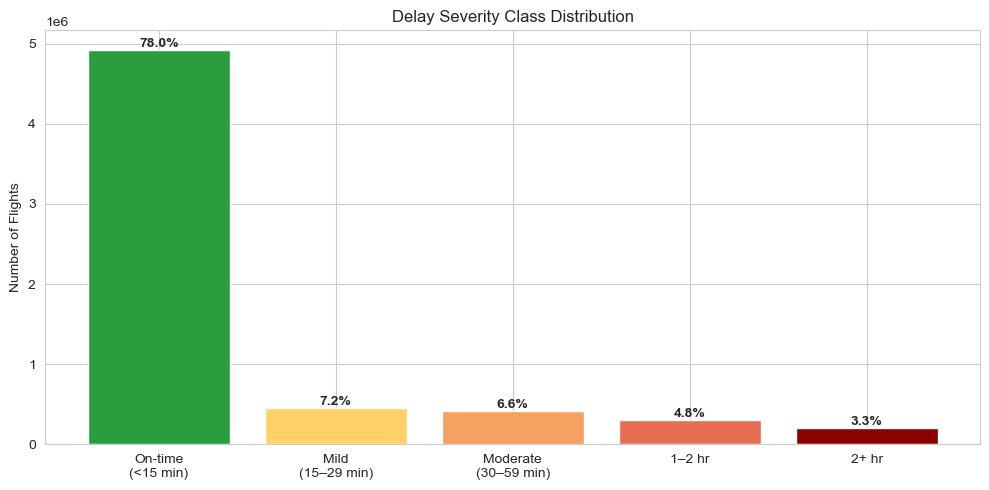

DELAY_CLASS
0    78.03
1     7.22
2     6.61
3     4.80
4     3.34
Name: count, dtype: float64


In [4]:
# Class distribution across the 5 severity buckets
class_counts = df["DELAY_CLASS"].value_counts().sort_index()
class_labels = [
    "On-time\n(<15 min)",
    "Mild\n(15–29 min)",
    "Moderate\n(30–59 min)",
    "1–2 hr",
    "2+ hr",
]
class_pct = class_counts / class_counts.sum() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    class_labels,
    class_counts.values,
    color=["#2a9d3f", "#FFD166", "#F4A261", "#E76F51", "#8B0000"],
)
ax.set_ylabel("Number of Flights")
ax.set_title("Delay Severity Class Distribution")
ax.bar_label(bars, labels=[f"{p:.1f}%" for p in class_pct], fontweight="bold")
plt.tight_layout()
plt.show()

print(class_pct.round(2))


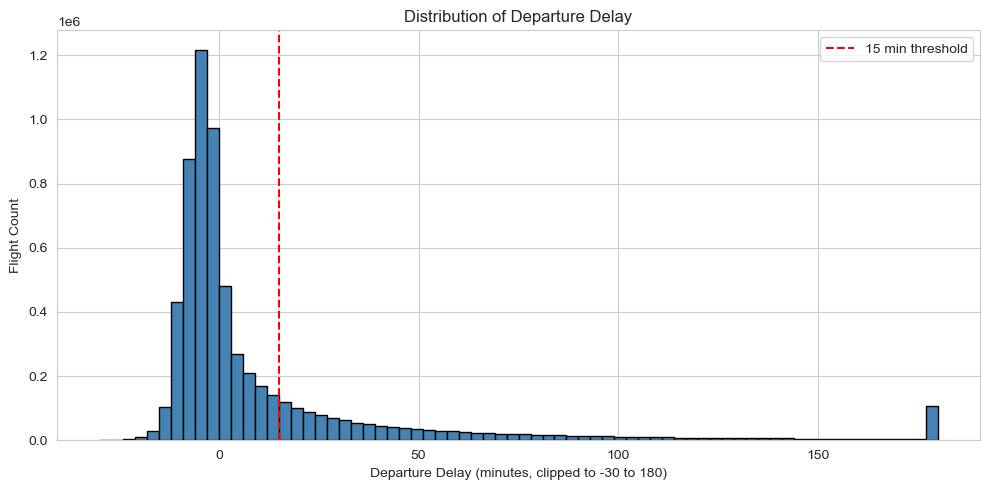

count    6304794.0
mean          13.7
std           57.8
min         -115.0
50%           -2.0
95%           90.0
max         4352.0
Name: DEP_DELAY, dtype: float64


In [5]:
# Histogram of DEP_DELAY — clipped to -30 to 180 min for outliers
clipped = df["DEP_DELAY"].clip(-30, 180)
plt.figure(figsize=(10, 5))
plt.hist(clipped, bins=70, color="steelblue", edgecolor="black")
plt.axvline(15, color="red", linestyle="--", label="15 min threshold")
plt.xlabel("Departure Delay (minutes, clipped to -30 to 180)")
plt.ylabel("Flight Count")
plt.title("Distribution of Departure Delay")
plt.legend()
plt.tight_layout()
plt.show()

print(df["DEP_DELAY"].describe(percentiles=[0.5, 0.95]).round(1))


---
## 2. Carrier Analysis

Which airlines delay the most? Do different carriers get delayed for different reasons?

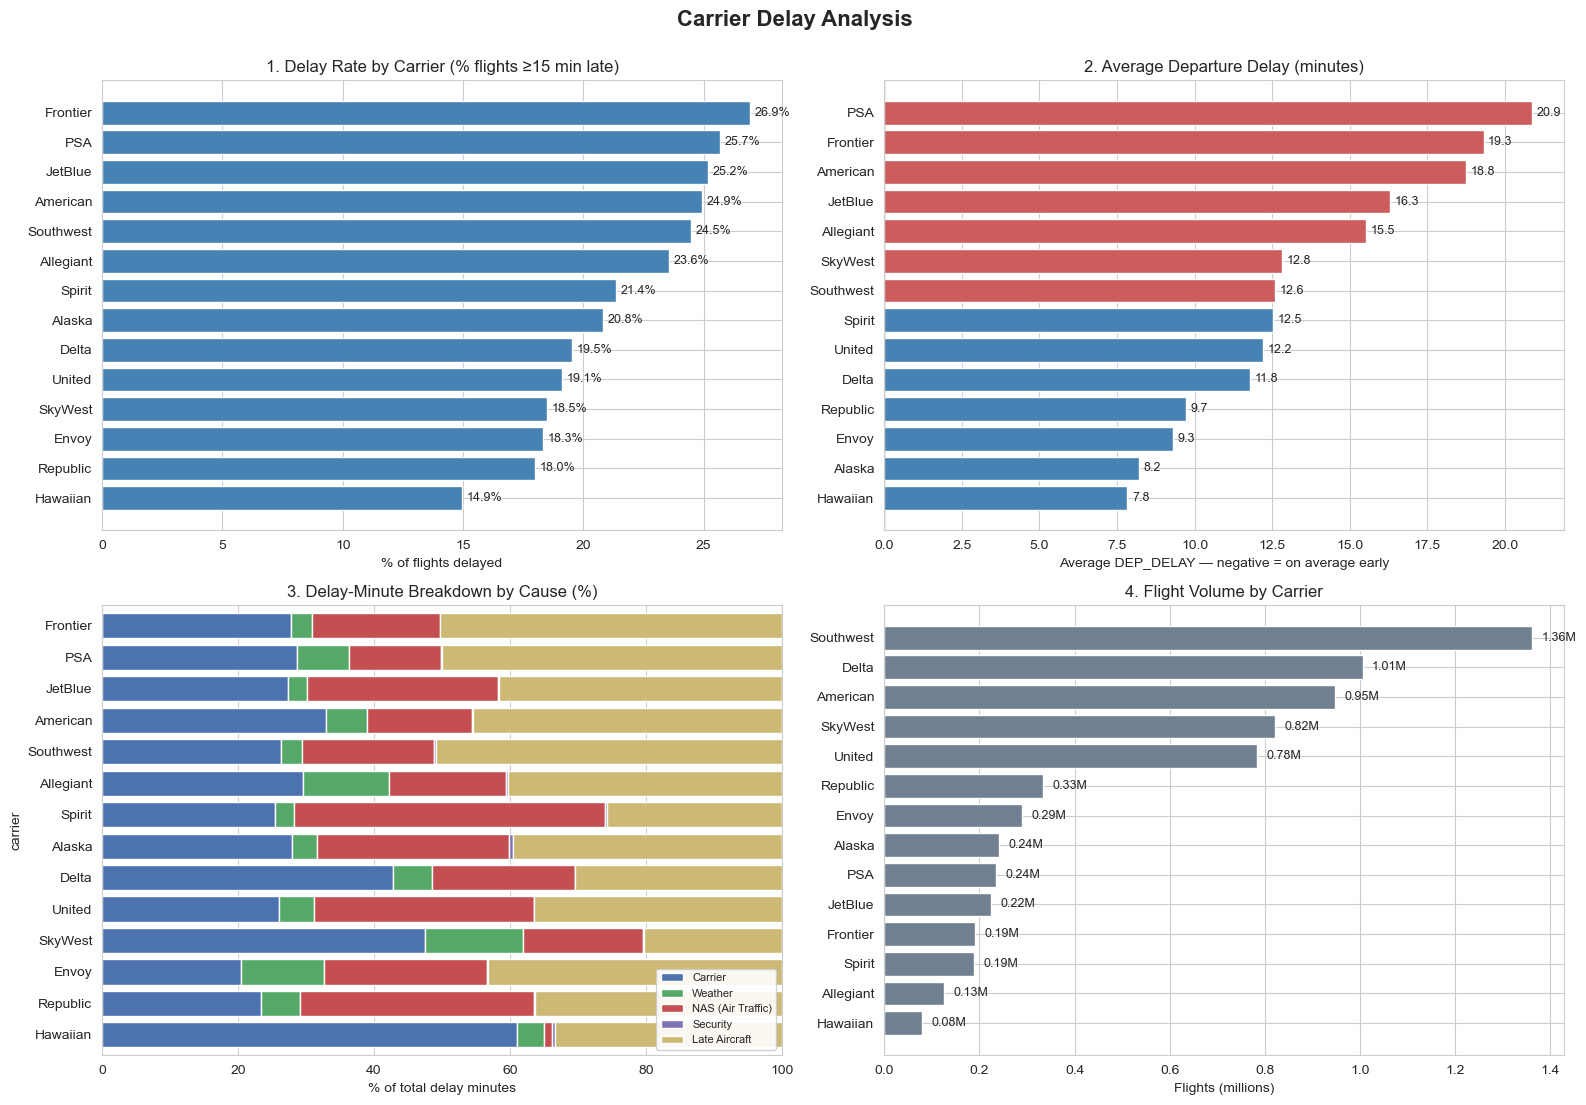

In [6]:
# Load only the columns needed for carrier analysis
cols = [
    "OP_UNIQUE_CARRIER",
    "DEP_DEL15",
    "DEP_DELAY",
    "CANCELLED",
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
]
df_car = pd.read_parquet("combined.parquet", columns=cols)

# Drop cancelled flights
df_car = df_car[df_car["CANCELLED"] != 1].copy()

# IATA code → readable name (makes plots interpretable)
carrier_names = {
    "AA": "American",
    "AS": "Alaska",
    "B6": "JetBlue",
    "DL": "Delta",
    "F9": "Frontier",
    "G4": "Allegiant",
    "HA": "Hawaiian",
    "MQ": "Envoy",
    "NK": "Spirit",
    "OH": "PSA",
    "OO": "SkyWest",
    "UA": "United",
    "WN": "Southwest",
    "YX": "Republic",
    "9E": "Endeavor",
    "YV": "Mesa",
    "EV": "ExpressJet",
    "VX": "Virgin America",
}
df_car["carrier"] = (
    df_car["OP_UNIQUE_CARRIER"].map(carrier_names).fillna(df_car["OP_UNIQUE_CARRIER"])
)

# Aggregate everything in one groupby
agg = df_car.groupby("carrier").agg(
    n_flights=("DEP_DEL15", "size"),
    delay_rate=("DEP_DEL15", "mean"),
    avg_dep_delay=("DEP_DELAY", "mean"),
    carrier_delay=("CARRIER_DELAY", "sum"),
    weather_delay=("WEATHER_DELAY", "sum"),
    nas_delay=("NAS_DELAY", "sum"),
    security_delay=("SECURITY_DELAY", "sum"),
    late_aircraft_delay=("LATE_AIRCRAFT_DELAY", "sum"),
)
agg["delay_rate_pct"] = agg["delay_rate"] * 100

# % breakdown of delay minutes by cause
reason_cols = [
    "carrier_delay",
    "weather_delay",
    "nas_delay",
    "security_delay",
    "late_aircraft_delay",
]
totals = agg[reason_cols].sum(axis=1).replace(0, np.nan)
reason_pct = agg[reason_cols].div(totals, axis=0) * 100

# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Carrier Delay Analysis", fontsize=16, fontweight="bold", y=1.00)

# Plot 1 — delay rate (% of flights 15+ min late), sorted
ax = axes[0, 0]
d = agg["delay_rate_pct"].sort_values()
bars = ax.barh(d.index, d.values, color="steelblue")
ax.set_title("1. Delay Rate by Carrier (% flights ≥15 min late)")
ax.set_xlabel("% of flights delayed")
for bar, v in zip(bars, d.values):
    ax.text(
        v + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}%",
        va="center",
        fontsize=9,
    )

# Plot 2 — average departure delay (minutes)
ax = axes[0, 1]
d = agg["avg_dep_delay"].sort_values()
med = d.median()
colors = [
    "#2a9d3f" if v < 0 else "steelblue" if v < med else "indianred" for v in d.values
]
bars = ax.barh(d.index, d.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("2. Average Departure Delay (minutes)")
ax.set_xlabel("Average DEP_DELAY — negative = on average early")
for bar, v in zip(bars, d.values):
    ax.text(
        v + (0.15 if v >= 0 else -0.15),
        bar.get_y() + bar.get_height() / 2,
        f"{v:.1f}",
        va="center",
        ha="left" if v >= 0 else "right",
        fontsize=9,
    )

# Plot 3 — stacked % of delay minutes by cause, per carrier
ax = axes[1, 0]
order = agg["delay_rate_pct"].sort_values(ascending=False).index
plot_df = reason_pct.loc[order].copy()
plot_df.columns = [
    "Carrier",
    "Weather",
    "NAS (Air Traffic)",
    "Security",
    "Late Aircraft",
]
plot_df.plot(
    kind="barh",
    stacked=True,
    ax=ax,
    color=["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"],
    width=0.8,
)
ax.set_title("3. Delay-Minute Breakdown by Cause (%)")
ax.set_xlabel("% of total delay minutes")
ax.set_xlim(0, 100)
ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
ax.invert_yaxis()

# Plot 4 — flight volume per carrier
ax = axes[1, 1]
d = (agg["n_flights"] / 1e6).sort_values()
bars = ax.barh(d.index, d.values, color="slategray")
ax.set_title("4. Flight Volume by Carrier")
ax.set_xlabel("Flights (millions)")
for bar, v in zip(bars, d.values):
    ax.text(
        v + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{v:.2f}M",
        va="center",
        fontsize=9,
    )

plt.tight_layout()
plt.show()


In [7]:
print("=== Summary (sorted by delay rate, best → worst) ===")
summary = agg[["n_flights", "delay_rate_pct", "avg_dep_delay"]].sort_values(
    "delay_rate_pct"
)
summary["n_flights"] = summary["n_flights"].map(lambda x: f"{x:>10,}")
print(summary.to_string(float_format="%.2f"))

print("\n=== Delay-cause mix, % of delay minutes (worst carrier first) ===")
print(reason_pct.loc[order].round(1).to_string())

best = agg["delay_rate_pct"].idxmin()
worst = agg["delay_rate_pct"].idxmax()
print(
    f"\nMost reliable: {best}  ({agg.loc[best, 'delay_rate_pct']:.1f}% delayed, "
    f"avg {agg.loc[best, 'avg_dep_delay']:.1f} min)"
)
print(
    f"Worst:         {worst} ({agg.loc[worst, 'delay_rate_pct']:.1f}% delayed, "
    f"avg {agg.loc[worst, 'avg_dep_delay']:.1f} min)"
)


=== Summary (sorted by delay rate, best → worst) ===
            n_flights  delay_rate_pct  avg_dep_delay
carrier                                             
Hawaiian       79,294           14.94           7.84
Republic      332,966           18.00           9.73
Envoy         290,099           18.33           9.30
SkyWest       822,229           18.50          12.81
United        782,780           19.13          12.20
Delta       1,005,316           19.53          11.78
Alaska        241,732           20.83           8.19
Spirit        188,947           21.37          12.54
Allegiant     126,234           23.56          15.51
Southwest   1,360,967           24.46          12.60
American      946,979           24.92          18.75
JetBlue       224,044           25.20          16.29
PSA           235,426           25.69          20.86
Frontier      191,216           26.91          19.31

=== Delay-cause mix, % of delay minutes (worst carrier first) ===
           carrier_delay  weathe

---
## 3. Time Patterns

When do delays happen? Morning vs evening, weekday vs weekend, seasonal patterns.

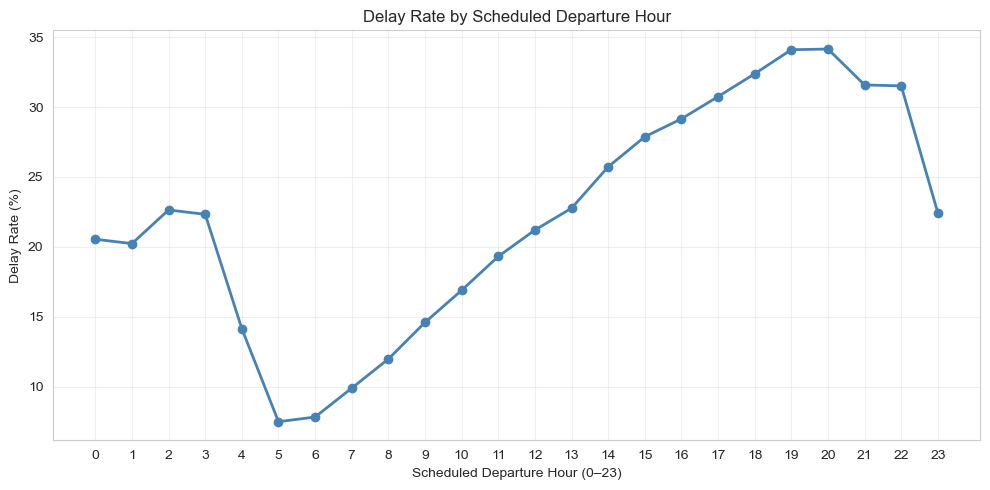

Best hour:   5:00  (7.5% delayed)
Worst hour: 20:00  (34.1% delayed)


In [8]:
# Delay rate across hour of day
hour_delay = df[df["DEP_HOUR"] < 24].groupby("DEP_HOUR")["DEP_DEL15"].mean() * 100

plt.figure(figsize=(10, 5))
plt.plot(
    hour_delay.index, hour_delay.values, marker="o", linewidth=2, color="steelblue"
)
plt.xlabel("Scheduled Departure Hour (0–23)")
plt.ylabel("Delay Rate (%)")
plt.title("Delay Rate by Scheduled Departure Hour")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Best hour:  {hour_delay.idxmin():>2}:00  ({hour_delay.min():.1f}% delayed)")
print(f"Worst hour: {hour_delay.idxmax():>2}:00  ({hour_delay.max():.1f}% delayed)")


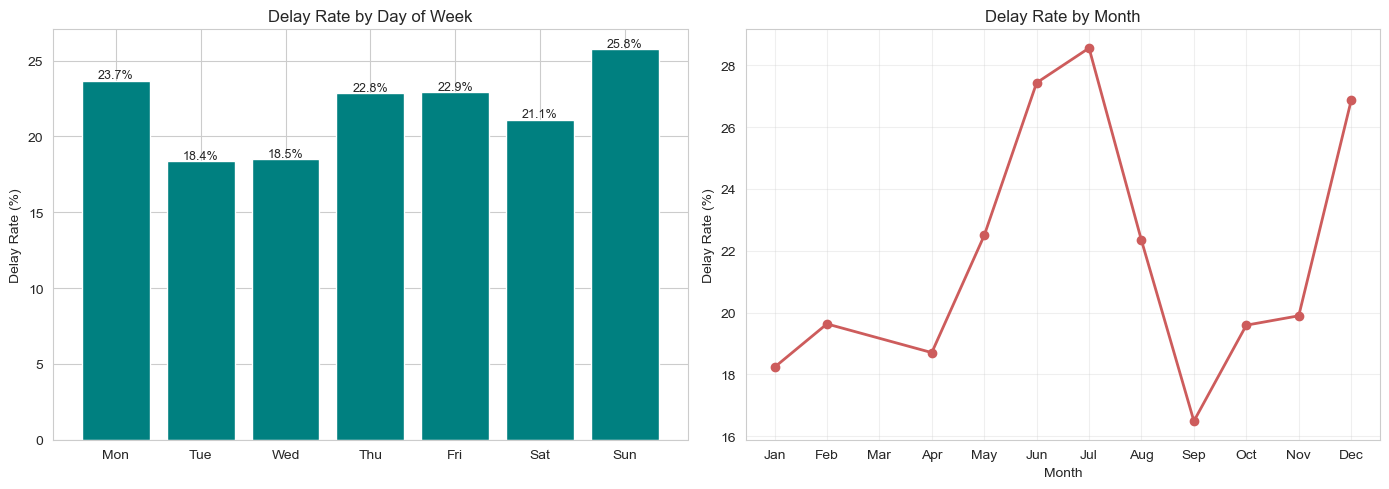

In [9]:
# Side-by-side: day-of-week and month
day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_delay = df.groupby("DAY_OF_WEEK")["DEP_DEL15"].mean() * 100
month_delay = df.groupby("MONTH")["DEP_DEL15"].mean() * 100
month_labels = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jun",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(day_labels, dow_delay.values, color="teal")
axes[0].set_ylabel("Delay Rate (%)")
axes[0].set_title("Delay Rate by Day of Week")
for i, v in enumerate(dow_delay.values):
    axes[0].text(i, v + 0.15, f"{v:.1f}%", ha="center", fontsize=9)

axes[1].plot(
    month_delay.index, month_delay.values, marker="o", linewidth=2, color="indianred"
)
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Delay Rate (%)")
axes[1].set_title("Delay Rate by Month")
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_labels)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 4. Geography & Distance

Where do delays happen, and does flight distance matter?

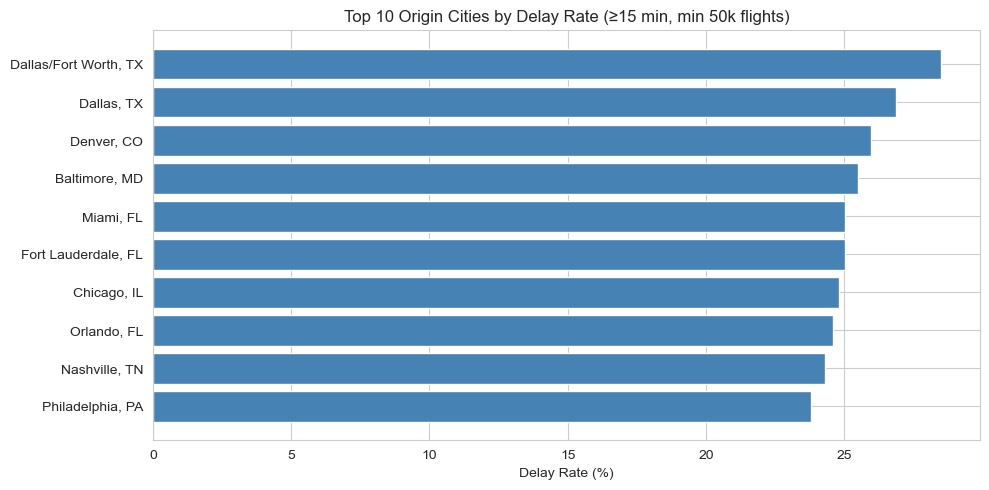

                           mean   count
ORIGIN_CITY_NAME                       
Dallas/Fort Worth, TX  0.284856  304421
Dallas, TX             0.268661   69612
Denver, CO             0.259637  313164
Baltimore, MD          0.255069   93759
Miami, FL              0.250378  109674
Fort Lauderdale, FL    0.250105   85532
Chicago, IL            0.248071  390541
Orlando, FL            0.245914  156343
Nashville, TN          0.242908  102409
Philadelphia, PA       0.238054   94428


In [10]:
# Reload raw for columns dropped/encoded during preprocessing
df_raw = pd.read_parquet(
    "combined.parquet",
    columns=[
        "CANCELLED",
        "DEP_DELAY",
        "ORIGIN_CITY_NAME",
        "DEST_CITY_NAME",
        "CARRIER_DELAY",
        "WEATHER_DELAY",
        "NAS_DELAY",
        "SECURITY_DELAY",
        "LATE_AIRCRAFT_DELAY",
    ],
)
df_raw = df_raw[df_raw["CANCELLED"] == 0].dropna(subset=["DEP_DELAY"])
df_raw["DELAYED"] = (df_raw["DEP_DELAY"] >= 15).astype(int)

# Delay rate by origin city (min 50k flights to cut noise from small airports)
city_stats = df_raw.groupby("ORIGIN_CITY_NAME")["DELAYED"].agg(["mean", "count"])
top_cities = city_stats[city_stats["count"] >= 50000].nlargest(10, "mean")

plt.figure(figsize=(10, 5))
plt.barh(top_cities.index, top_cities["mean"] * 100, color="steelblue")
plt.xlabel("Delay Rate (%)")
plt.title("Top 10 Origin Cities by Delay Rate (≥15 min, min 50k flights)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_cities)


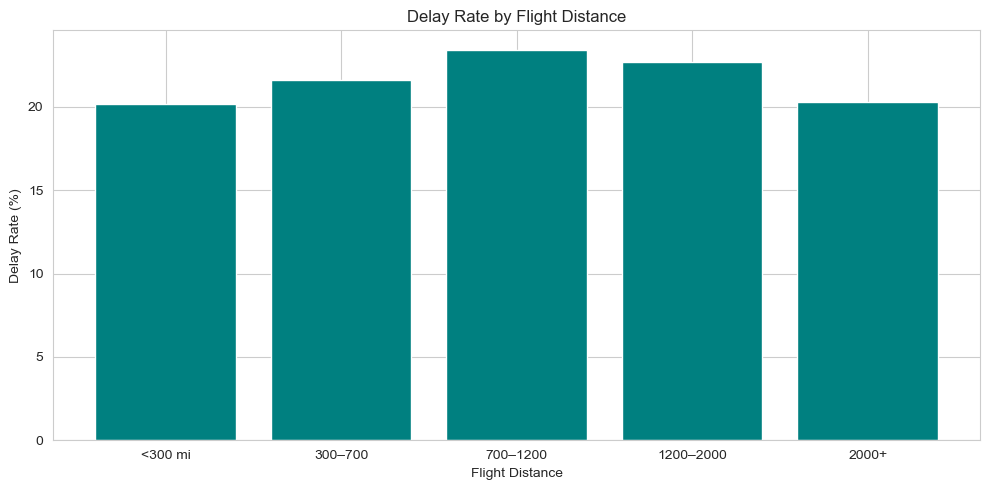

             delay_rate_pct  n_flights
DIST_BUCKET                           
<300 mi           20.139999     969654
300–700           21.610001    2221056
700–1200          23.410000    1852385
1200–2000         22.680000     856602
2000+             20.309999     405097


In [11]:
# Bin distance into 5 buckets for a clearer trend
bins = [0, 300, 700, 1200, 2000, 6000]
labels = ["<300 mi", "300–700", "700–1200", "1200–2000", "2000+"]
df["DIST_BUCKET"] = pd.cut(df["DISTANCE"], bins=bins, labels=labels)
grouped = df.groupby("DIST_BUCKET", observed=True)
bucket_delay = grouped["DEP_DEL15"].mean() * 100
bucket_count = grouped.size()

plt.figure(figsize=(10, 5))
plt.bar(bucket_delay.index, bucket_delay.values, color="teal")
plt.ylabel("Delay Rate (%)")
plt.xlabel("Flight Distance")
plt.title("Delay Rate by Flight Distance")
plt.tight_layout()
plt.show()

print(
    pd.DataFrame({"delay_rate_pct": bucket_delay.round(2), "n_flights": bucket_count})
)


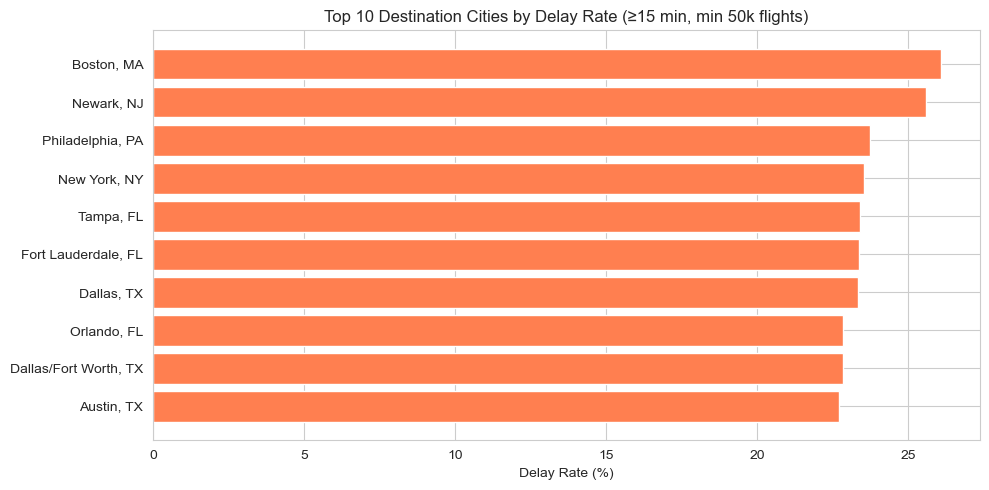

                           mean   count
DEST_CITY_NAME                         
Boston, MA             0.260796  138591
Newark, NJ             0.255905  116637
Philadelphia, PA       0.237523   94416
New York, NY           0.235333  233265
Tampa, FL              0.234029   76922
Fort Lauderdale, FL    0.233631   85468
Dallas, TX             0.233601   69593
Orlando, FL            0.228499  156154
Dallas/Fort Worth, TX  0.228481  304213
Austin, TX             0.227018   84676


In [12]:
# Top 10 destination cities by delay rate (pairs with origin cities above)
dest_stats = df_raw.groupby("DEST_CITY_NAME")["DELAYED"].agg(["mean", "count"])
top_dest = dest_stats[dest_stats["count"] >= 50000].nlargest(10, "mean")

plt.figure(figsize=(10, 5))
plt.barh(top_dest.index, top_dest["mean"] * 100, color="coral")
plt.xlabel("Delay Rate (%)")
plt.title("Top 10 Destination Cities by Delay Rate (≥15 min, min 50k flights)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(top_dest)


---
## 5. Correlation Matrix

Quick check for multicollinearity among numeric features before modeling.

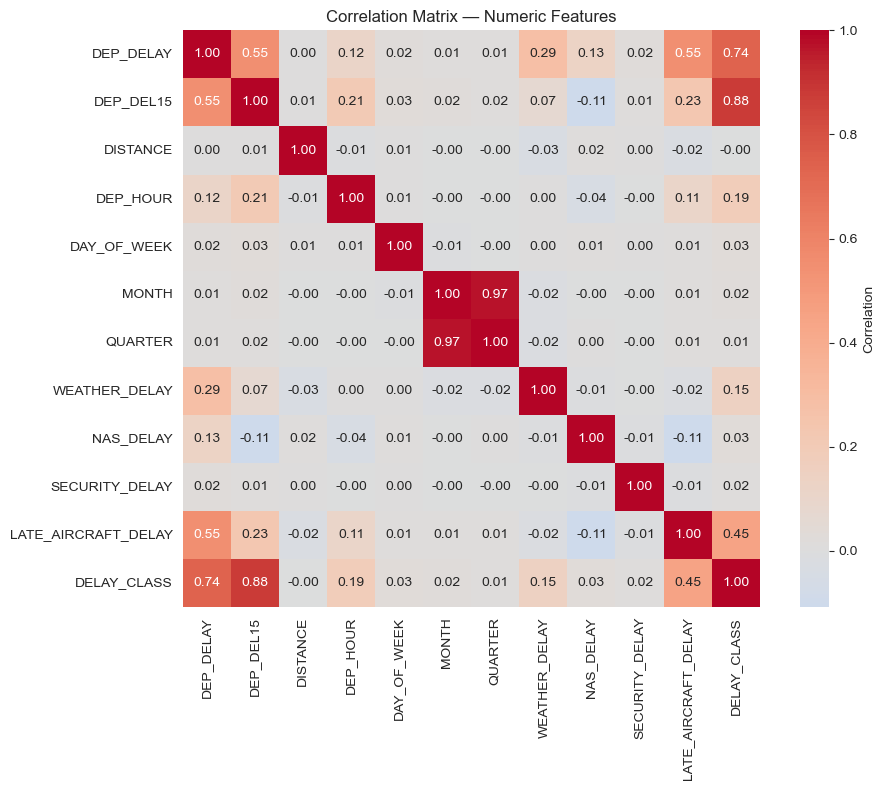

In [13]:
# Correlation matrix of core numeric features (excluding one-hot stuff)
numeric_cols = [
    "DEP_DELAY",
    "DEP_DEL15",
    "DISTANCE",
    "DEP_HOUR",
    "DAY_OF_WEEK",
    "MONTH",
    "QUARTER",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "DELAY_CLASS",
]
avail = [c for c in numeric_cols if c in df.columns]
corr = df[avail].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    cbar_kws={"label": "Correlation"},
)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()


---
## 6. Delay Causes Analysis

What are the root causes of flight delays? How do they contribute to total delay minutes?

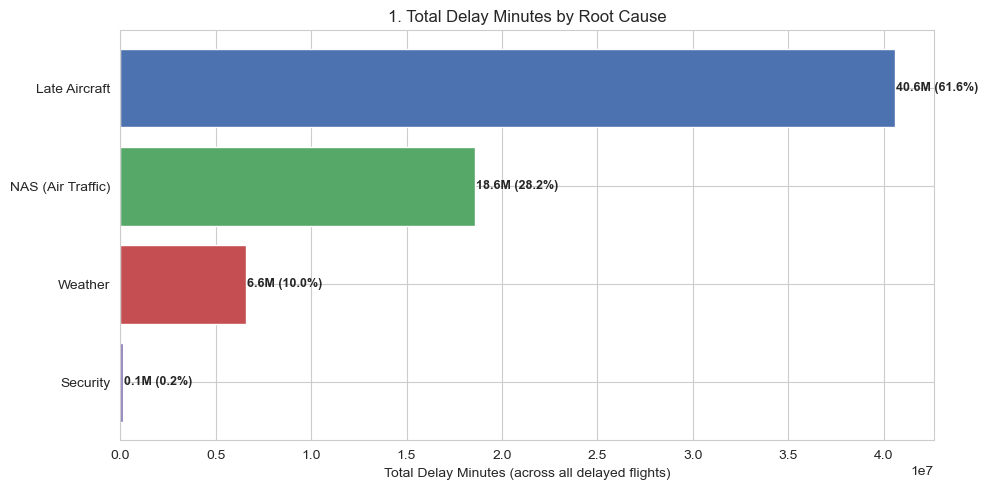

Total delay minutes across all delayed flights: 65,921,136

Delay minutes by cause:
  Late Aircraft.................   40,581,880 min ( 61.6%)
  NAS (Air Traffic).............   18,589,668 min ( 28.2%)
  Weather.......................    6,607,459 min ( 10.0%)
  Security......................      142,129 min (  0.2%)


In [ ]:
# Analyze root causes of delays
# Focus on flights with delays (DEP_DEL15 == 1 or DEP_DELAY > 0)
df_delayed = df[df["DEP_DELAY"] > 0].copy()

# Sum total delay minutes by cause
delay_causes = {
    "Weather": df_delayed["WEATHER_DELAY"].sum(),
    "NAS (Air Traffic)": df_delayed["NAS_DELAY"].sum(),
    "Security": df_delayed["SECURITY_DELAY"].sum(),
    "Late Aircraft": df_delayed["LATE_AIRCRAFT_DELAY"].sum(),
}

# Remove zero-value causes for clarity
delay_causes = {k: v for k, v in delay_causes.items() if v > 0}
delay_causes_sorted = dict(sorted(delay_causes.items(), key=lambda x: x[1], reverse=True))

# Total delay minutes
total_delay_minutes = sum(delay_causes_sorted.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("1. Total Delay Minutes by Root Cause", fontsize=12, fontweight="bold")

# Bar chart — total delay minutes by cause
ax = axes[0]
causes = list(delay_causes_sorted.keys())
minutes = list(delay_causes_sorted.values())
bars = ax.barh(causes, minutes, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
ax.set_xlabel("Total Delay Minutes (across all delayed flights)")
ax.set_title("Total Impact by Cause")
ax.invert_yaxis()

# Add value labels and percentages
for bar, minute in zip(bars, minutes):
    pct = (minute / total_delay_minutes) * 100
    ax.text(
        minute + 50000,
        bar.get_y() + bar.get_height() / 2,
        f"{minute/1e6:.1f}M ({pct:.1f}%)",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

# Pie chart — % of total delay minutes by cause
causes_list = list(delay_causes_sorted.keys())
minutes_list = list(delay_causes_sorted.values())
colors_pie = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]
wedges, texts, autotexts = axes[1].pie(
    minutes_list,
    labels=causes_list,
    autopct="%1.1f%%",
    colors=colors_pie[:len(causes_list)],
    startangle=90,
)
axes[1].set_title("Contribution to Total Delay Minutes")
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

print(f"Total delay minutes across all delayed flights: {total_delay_minutes:,.0f}")
print("\nDelay minutes by cause:")
for cause, minutes in delay_causes_sorted.items():
    pct = (minutes / total_delay_minutes) * 100
    print(f"  {cause:.<30} {minutes:>12,.0f} min ({pct:>5.1f}%)")

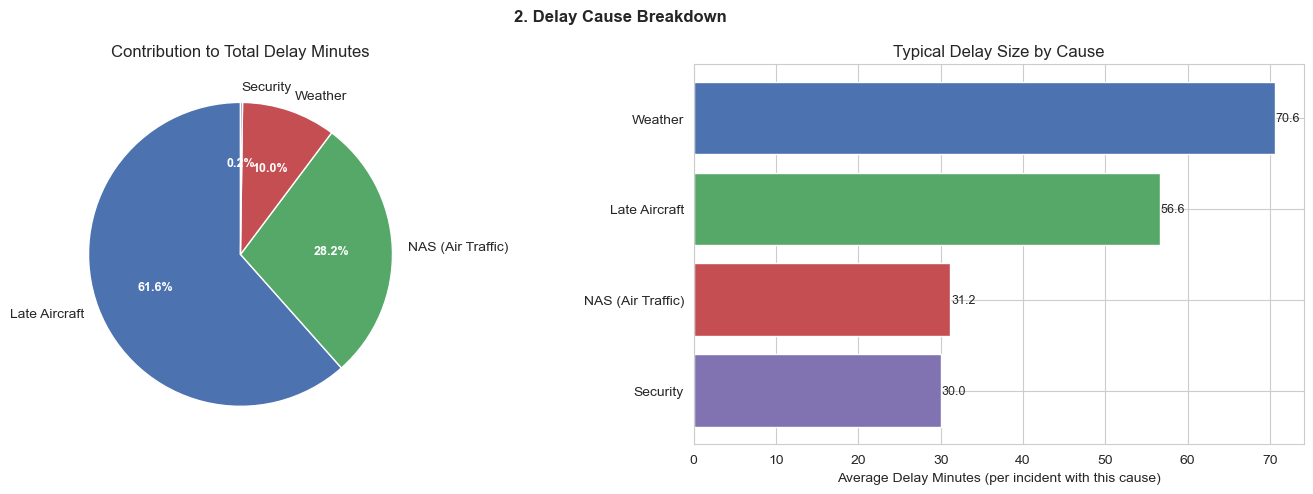


Average delay minutes per incident (when cause is present):
  Weather.......................  70.58 min
  Late Aircraft.................  56.59 min
  NAS (Air Traffic).............  31.18 min
  Security......................  30.01 min


In [ ]:
# Side-by-side: Bar chart of avg delay size and pie chart of avg contribution by cause
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("2. Delay Cause Breakdown — Average Impact", fontsize=12, fontweight="bold")

# Bar chart — average delay minutes per incident by cause
avg_delays = {}
for cause, col in zip(
    ["Weather", "NAS (Air Traffic)", "Security", "Late Aircraft"],
    ["WEATHER_DELAY", "NAS_DELAY", "SECURITY_DELAY", "LATE_AIRCRAFT_DELAY"],
):
    # Only non-zero delays
    non_zero = df_delayed[df_delayed[col] > 0][col]
    if len(non_zero) > 0:
        avg_delays[cause] = non_zero.mean()

avg_delays_sorted = dict(sorted(avg_delays.items(), key=lambda x: x[1], reverse=True))
avg_causes = list(avg_delays_sorted.keys())
avg_values = list(avg_delays_sorted.values())

bars = axes[0].barh(avg_causes, avg_values, color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
axes[0].set_xlabel("Average Delay Minutes (per incident with this cause)")
axes[0].set_title("Typical Delay Size by Cause")
axes[0].invert_yaxis()

for bar, val in zip(bars, avg_values):
    axes[0].text(
        val + 0.1,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center",
        fontsize=9,
    )

# Pie chart — % contribution to total average delay
total_avg_delay = sum(avg_values)
colors_pie = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
wedges, texts, autotexts = axes[1].pie(
    avg_values,
    labels=avg_causes,
    autopct="%1.1f%%",
    colors=colors_pie[:len(avg_causes)],
    startangle=90,
)
axes[1].set_title("Avg Contribution to Total Delay Minutes")
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(9)

plt.tight_layout()
plt.show()

print("\nAverage delay minutes per incident (when cause is present):")
for cause, avg in avg_delays_sorted.items():
    pct = (avg / total_avg_delay) * 100
    print(f"  {cause:.<30} {avg:>6.2f} min ({pct:>5.1f}%)")